In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings('ignore')
from concurrent.futures import ProcessPoolExecutor, as_completed

In [2]:
dirs='~/shared/ugit0034/IAP/IAP_202609/profiles/'
diro='~/scratch/ML4O2_temp/'
#pfm=['OSD','CTD','PFL']
yr0=[1965]
yr1=[2025]
z1=[119]
#print(np.round(1.49))
ds=xr.open_dataset(dirs+'CAS_DO_profiles_1992_9.nc')
z=ds['stddepth'].to_numpy()
np.save('depth.npy',z)
ds.dims['nProfiles']

1051

In [3]:
dirsz='~/shared/ugit0034/Zhankun/202608/'
ds0=xr.open_dataset(dirsz+'Oxygen_OSD_2000.nc')
zstd=ds0.depth.to_numpy()[:102]

In [9]:
def bin_data(year,mon):
    # stype: 0=OSD, 1=CTD, 2=PFL
    z=np.load('depth.npy')
    ds=xr.open_dataset(dirs+f'CAS_DO_profiles_{year}_{mon}.nc')
    Np=ds.dims['nProfiles']
    Nz=ds.dims['nStdDepth']
    print(year,mon,Np,Nz)
    tmptrc=np.zeros((z1[0],180,360))
    tmplon=np.zeros((180,360))
    tmplat=np.zeros((180,360))
    tmpcnt=np.zeros((z1[0],180,360),dtype=np.int32)
    tmpcntxy=np.zeros((180,360),dtype=np.int32)
    for n in range(Np):
        trc=np.zeros(z1[0])
        trc=ds.DOprofile_stddepth[:,n].to_numpy()
        ptype=ds.DOprofile_info_string[1,n].values # OSD, etc
        lat=ds.DOprofile_info_record[6,n].values # lat
        lon=ds.DOprofile_info_record[7,n].values # lon
        i0=int(np.round(lon))
        # ad-hoc fix for longitude error
        if i0==360:
            i0=359
        j0=int(np.round(lat)+90)
        if (i0>=0)&(i0<360)&(j0>=0)&(j0<180): 
            cntz=np.where(np.isnan(trc)==False,1,0)
            trcz=np.where(np.isnan(trc)==False,trc,0)
            tmptrc[:,j0,i0]=tmptrc[:,j0,i0]+trcz
            tmpcnt[:,j0,i0]=tmpcnt[:,j0,i0]+cntz
            tmpcntxy[j0,i0]=tmpcntxy[j0,i0]+1
            tmplat[j0,i0]=tmplat[j0,i0]+lat
            tmplon[j0,i0]=tmplon[j0,i0]+lon
    #
    trcbin = tmptrc/tmpcnt
    lonbin = tmplon/tmpcntxy
    latbin = tmplat/tmpcntxy
    #
    #time=np.arange(f'{year}-{mon}',f'{year}-{mon}',dtype='datetime64[M]')
    time=np.array([f'{year}-{str(mon).zfill(2)}'],dtype='datetime64[M]')
    x=np.arange(0,360,1)+0.5
    y=np.arange(-90,90,1)+0.5
    da=xr.DataArray(data=trcbin[np.newaxis,:,:,:],name='Oxygen',dims=['time','depth','lat','lon'],
                   coords={'time':time,'depth':z,'lat':y,'lon':x}).interp(depth=zstd).astype('float32')
    da[:,0,:,:]=da[:,1,:,:]
    ds=da.to_dataset()
    ds['sample_count']=xr.DataArray(data=tmpcnt[np.newaxis,:,:,:],dims=['time','depth','lat','lon'],
                   coords={'time':time,'depth':z,'lat':y,'lon':x}).interp(depth=zstd).astype('int16')
    ds['profile_count']=xr.DataArray(data=tmpcntxy[np.newaxis,:,:],dims=['time','lat','lon'],
                   coords={'time':time,'lat':y,'lon':x}).astype('int16')
    ds['latitude']=xr.DataArray(data=latbin[np.newaxis,:,:],dims=['time','lat','lon'],
                   coords={'time':time,'lat':y,'lon':x}).astype('float32')
    ds['longitude']=xr.DataArray(data=lonbin[np.newaxis,:,:],dims=['time','lat','lon'],
                   coords={'time':time,'lat':y,'lon':x}).astype('float32')
    ds=ds.interp(depth=zstd)
    ds.to_netcdf(f'{diro}binned_CAS_{year}-{mon}.nc')
    return 1

In [10]:
yrs=np.arange(yr0[0],yr1[0]+1,1)
tasks=[(year,mon) for year in yrs for mon in range(1,13)]
#
with ProcessPoolExecutor(max_workers=16) as ex:
    futures={ex.submit(bin_data,year,mon):(year,mon) for year,mon in tasks}
    for fut in as_completed(futures):
        year,mon=futures[fut]
        try:
            fut.result()
        except Exception as e:
            print(f'FAILED {year}-{mon}: {e}')

1965 196619651966 3 15231966  21965 1965119  19654
1121531196619651965 1965 1965     1965  1965 7977419653110210536  1 119   119 8408    12  1015
11915 1457 9
 1198311267 119
10  
875   19301578866119 119  
1191569
 
  119119119 
919119

 
119
119119


1966 5 1104 119
1966 6 1429 119
1966 7 1688 119
1966 81966  17169  1601119 
119
1966 101966  102911 119 876
 119
1966 12 662 119
1967 1 633 119
1967 2 1508 119
19671967  43  1311 1139 119119

1967 5 1373 119
1967 6 1419 119
1967 7 1671 119
1967 8 1922 119
1967 9 1370 119
1967 10 1050 119
1967 11 1112 119
1967 12 548 119
1968 11968  8002  1191503
 119
1968 3 1114 119
1968 4 1250 119
1968 5 1591 119
1968 6 1515 119
1968 7 1380 119
1968 8 1195 119
1968 91968  1096 10119
 1460 119
19681968  12 11834  1367 119119

1969 1 1007 1969119
 2 1679 119
1969 3 1257 119
1969 4 1477 119
1969 5 15251969  6119
 1680 119
1969 7 1851 119
1969 8 1529 119
1969 9 1176 119
1969 10 19691771  11911
 1075 119
1969 12 1090 119
1970 1 1057 119
1970 2 1456 119
1970 

In [11]:
def merge_year(yr):
    ds1=xr.open_mfdataset(f'{diro}binned_CAS_{yr}-*')
    ds1.to_netcdf(f'{diro}Oxygen_IAP_1x1bin_{yr}.nc')
    ds1.close()
    return yr

with ProcessPoolExecutor(max_workers=12) as ex:
    for yr in ex.map(merge_year, yrs):
        print('merged', yr)

merged 1965
merged 1966
merged 1967
merged 1968
merged 1969
merged 1970
merged 1971
merged 1972
merged 1973
merged 1974
merged 1975
merged 1976
merged 1977
merged 1978
merged 1979
merged 1980
merged 1981
merged 1982
merged 1983
merged 1984
merged 1985
merged 1986
merged 1987
merged 1988
merged 1989
merged 1990
merged 1991
merged 1992
merged 1993
merged 1994
merged 1995
merged 1996
merged 1997
merged 1998
merged 1999
merged 2000
merged 2001
merged 2002
merged 2003
merged 2004
merged 2005
merged 2006
merged 2007
merged 2008
merged 2009
merged 2010
merged 2011
merged 2012
merged 2013
merged 2014
merged 2015
merged 2016
merged 2017
merged 2018
merged 2019
merged 2020
merged 2021
merged 2022
merged 2023
merged 2024
merged 2025


In [12]:
ds=xr.open_mfdataset(f'{diro}Oxygen_IAP_1x1bin_*',chunks={'time': 12}).astype('float32')
ds.to_netcdf(f'Oxygen_IAP_1x1bin_{yr0[0]}-{yr1[0]}.nc')
ds

<xarray.Dataset> Size: 39GB
Dimensions:        (time: 732, depth: 102, lat: 180, lon: 360)
Coordinates:
  * time           (time) datetime64[ns] 6kB 1965-01-01 ... 2025-12-01
  * lat            (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * lon            (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * depth          (depth) float64 816B 0.0 5.0 10.0 ... 5.3e+03 5.4e+03 5.5e+03
Data variables:
    Oxygen         (time, depth, lat, lon) float32 19GB dask.array<chunksize=(12, 102, 180, 360), meta=np.ndarray>
    sample_count   (time, depth, lat, lon) float32 19GB dask.array<chunksize=(12, 102, 180, 360), meta=np.ndarray>
    profile_count  (time, lat, lon) float32 190MB dask.array<chunksize=(12, 180, 360), meta=np.ndarray>
    latitude       (time, lat, lon) float32 190MB dask.array<chunksize=(12, 180, 360), meta=np.ndarray>
    longitude      (time, lat, lon) float32 190MB dask.array<chunksize=(12, 180, 360), meta=np.ndarray>

In [13]:
o2_monclim = ds.Oxygen.groupby('time.month').mean('time').to_numpy().astype('float32')
mon=np.arange(1,13,1)
depth=ds.depth
lat=ds.lat
lon=ds.lon
da=xr.DataArray(data=o2_monclim,name='o2',dims=['time','depth','lat','lon'],\
                coords={'time':mon,'depth':depth,'lat':lat,'lon':lon})

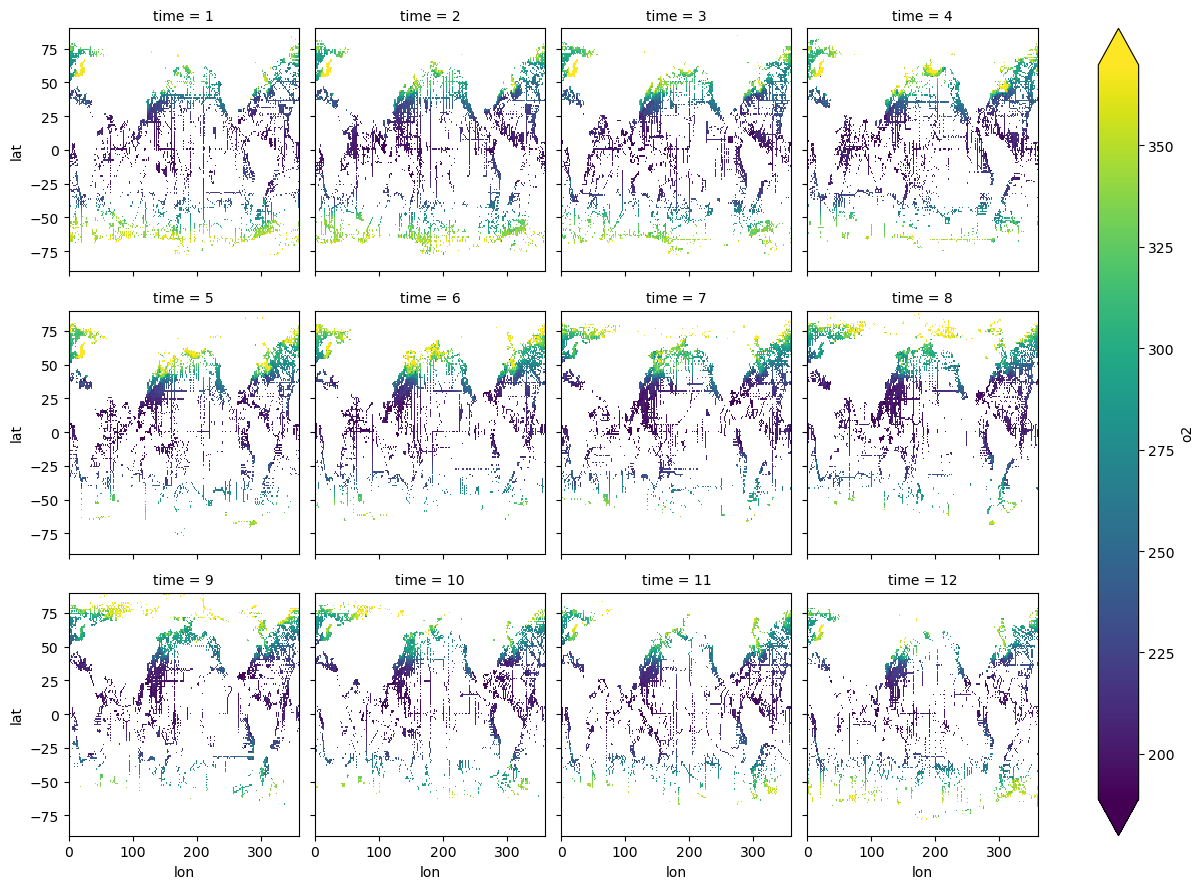

In [14]:
da.sel(depth=0).plot(col='time',col_wrap=4,robust=True)

In [15]:
o2c0=np.tile(o2_monclim,[3,1,1,1])
o2c =np.zeros_like(o2_monclim)
for n in range(12):
    o2c[n]=np.nanmean(o2c0[(n+12)-1:(n+12)+1,:,:,:],axis=0)

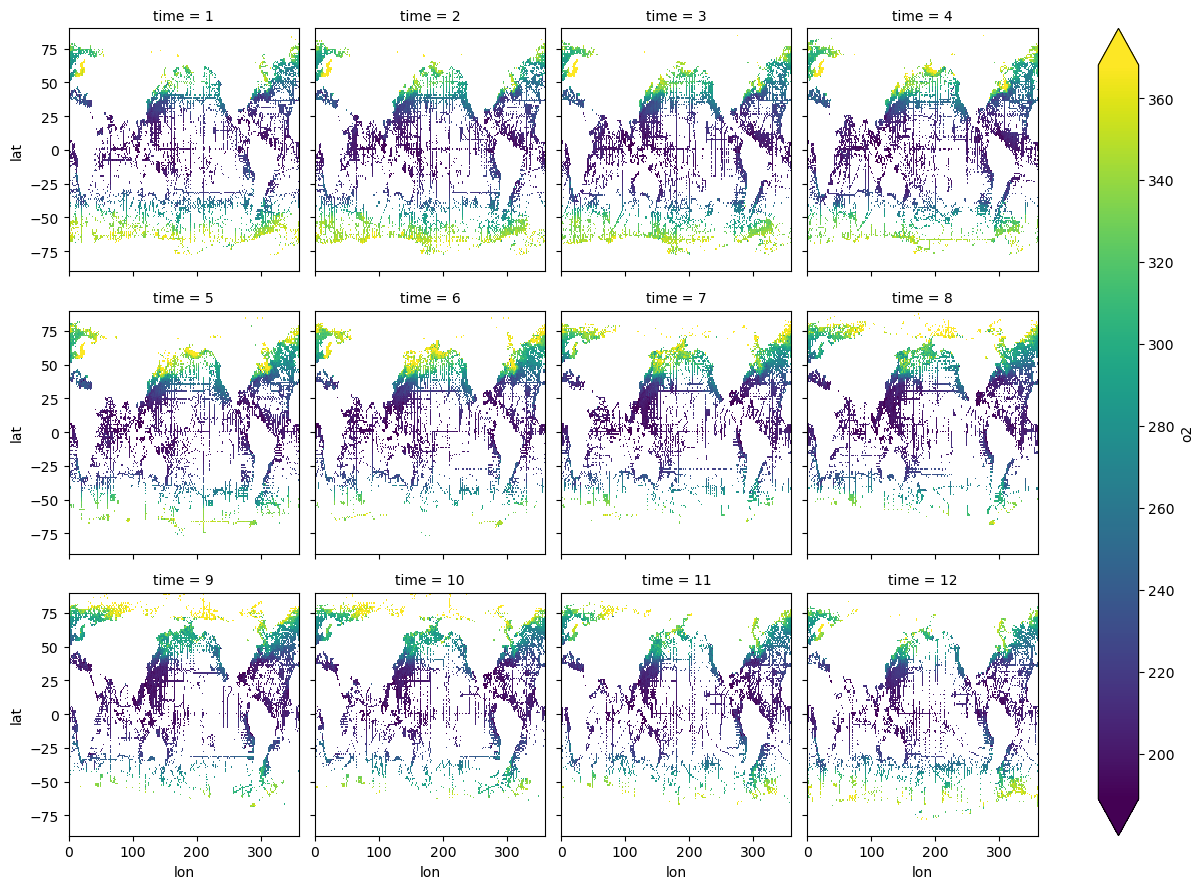

In [16]:
da=xr.DataArray(data=o2c,name='o2',dims=['time','depth','lat','lon'],\
                coords={'time':mon,'depth':zstd,'lat':lat,'lon':lon})
da[:,0,:,:]=da[:,1,:,:]
da.isel(depth=0).plot(col='time',col_wrap=4,robust=True)

In [17]:
ds=da.to_dataset()
ds.to_netcdf('Oxygen_IAP_1x1bin_mon_clim_lon0to360.nc')
ds

<xarray.Dataset> Size: 317MB
Dimensions:  (time: 12, depth: 102, lat: 180, lon: 360)
Coordinates:
  * time     (time) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * depth    (depth) float64 816B 0.0 5.0 10.0 15.0 ... 5.3e+03 5.4e+03 5.5e+03
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    o2       (time, depth, lat, lon) float32 317MB nan nan nan ... nan nan nan

In [18]:
ds0=ds.mean('time')
ds0.to_netcdf('Oxygen_IAP_1x1bin_ann_clim_lon0to360.nc')

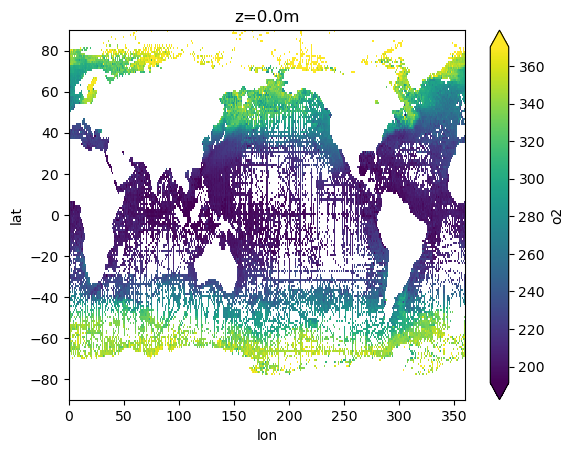

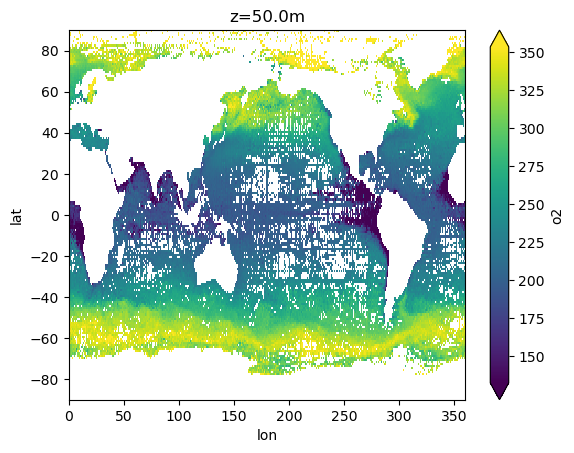

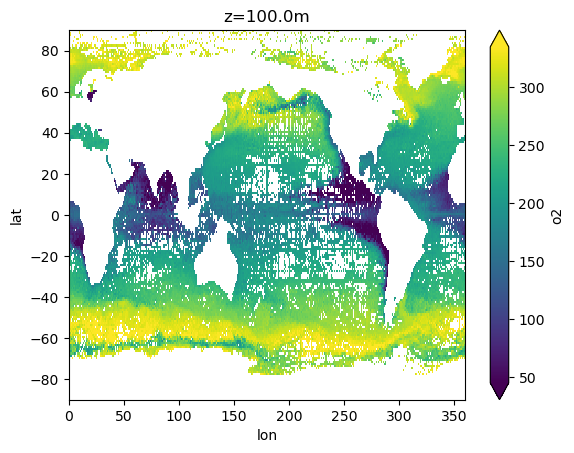

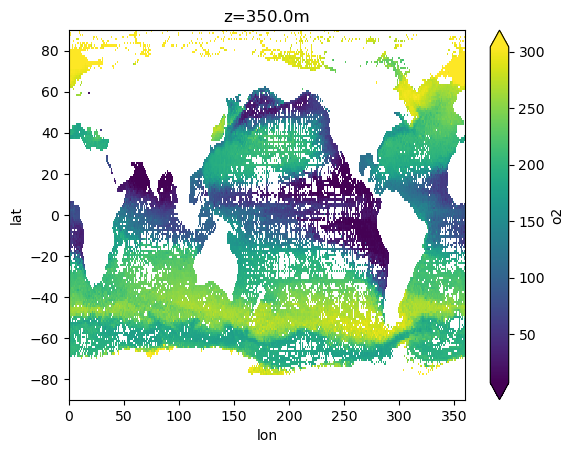

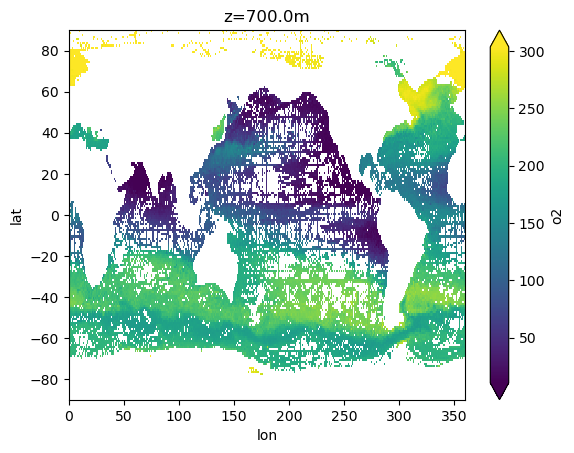

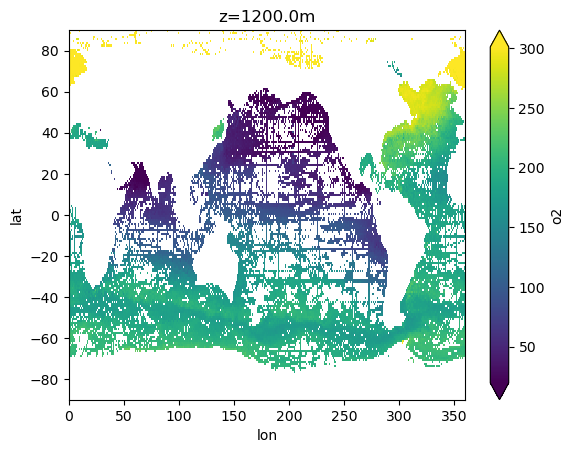

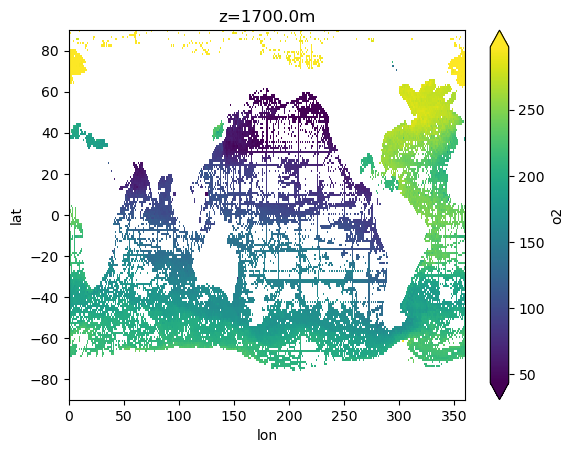

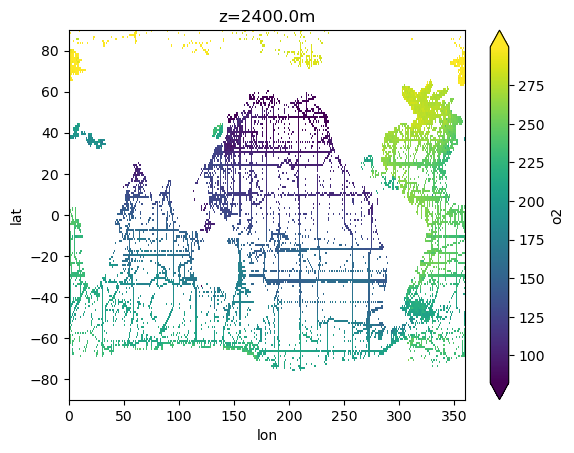

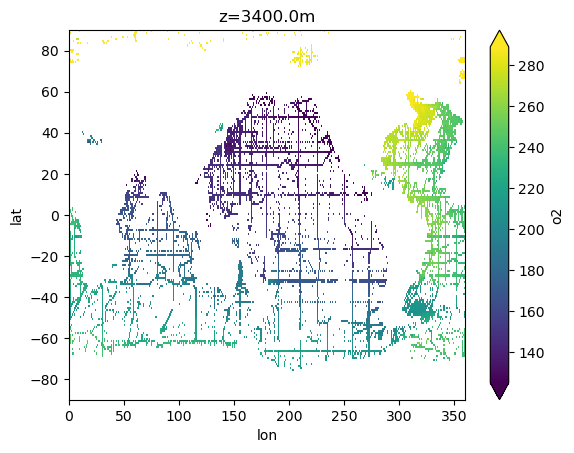

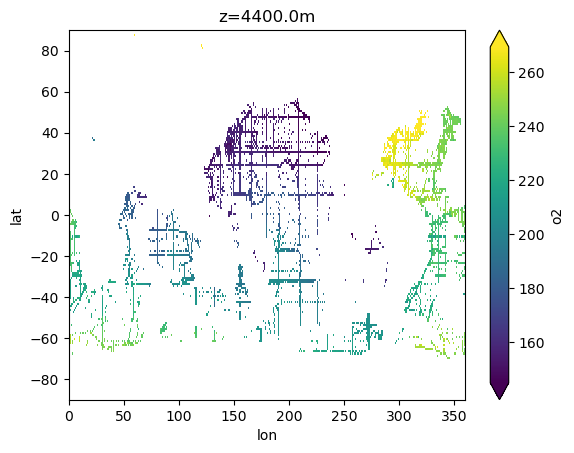

In [19]:
for n in range(10):
    ds0.o2[n*10,:,:].plot(robust=True)
    plt.title(f'z={ds0.depth[n*10].to_numpy()}m')
    plt.show()